# Plan:
- EDA:
    - Summary overview and basic pre-processing
    - qualitative univariate
    - qualitative multivariate
    - quantitative univariate
    - quantitative multivariate
    - whole dataset

In [1]:
import pandas as pd
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

# Constants
SEASON = '21-22'

In [3]:
raw_player_data = pd.read_csv('../data/raw/2021-2022 Football Player Stats.csv', sep=';', encoding='latin1')
raw_player_data = raw_player_data.copy()
# raw_player_data['season'] = SEASON

raw_player_data.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,1,Max Aarons,ENG,DF,Norwich City,Premier League,22.0,2000,34,32,...,0.03,1.41,1.16,0.0,0.06,0.03,5.53,0.47,1.59,22.7
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,34.0,1987,34,34,...,0.00,0.06,1.39,0.0,0.03,0.00,6.77,2.02,1.36,59.8
2,3,Salis Abdul Samed,GHA,MF,Clermont Foot,Ligue 1,22.0,2000,31,29,...,0.00,0.36,1.24,0.0,0.00,0.00,8.76,0.88,0.88,50.0
3,4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,29.0,1993,34,34,...,0.03,0.79,2.23,0.0,0.00,0.00,8.87,0.43,0.43,50.0
4,5,Charles Abi,FRA,FW,Saint-Étienne,Ligue 1,22.0,2000,1,1,...,0.00,2.00,0.00,0.0,0.00,0.00,4.00,2.00,0.00,100.0


In [35]:
# Rk is just an index column (sorted by last name). Names also include special characters, which will require normalisation
player_data = raw_player_data.drop('Rk', axis=1)
player_data['Player'] = player_data['Player'].apply(unidecode)

duplicate_player_count = player_data.duplicated(subset="Player").sum()
duplicates_found = duplicate_player_count > 0

if duplicates_found:
    print(f"{duplicate_player_count} duplicate Player names found.")
    duplicate_players = player_data[player_data.duplicated(subset='Player', keep=False)].sort_values(by='Player')
    display(duplicate_players)
else:
    print("No duplicates found")

136 duplicate Player names found.


,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
2691,Adama Traore,ESP,FWDF,Barcelona,La Liga,26.0,1996,11,4,382,...,0.48,8.33,0.00,0.00,0.0,0.0,6.67,0.71,0.71,50.0
2692,Adama Traore,ESP,FW,Wolves,Premier League,26.0,1996,20,10,1067,...,0.76,2.35,0.76,0.00,0.0,0.0,5.38,1.01,2.18,31.6
1611,Ainsley Maitland-Niles,ENG,DF,Roma,Serie A,24.0,1997,8,7,487,...,0.19,3.52,0.56,0.00,0.0,0.0,7.59,0.93,0.74,55.6
1612,Ainsley Maitland-Niles,ENG,MF,Arsenal,Premier League,24.0,1997,8,2,268,...,0.00,0.33,1.33,0.00,0.0,0.0,12.30,1.67,1.33,55.6
563,Andrea Conti,ITA,DFMF,Sampdoria,Serie A,28.0,1994,7,2,234,...,0.38,0.00,1.54,0.00,0.0,0.0,5.38,0.00,1.54,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1876,Vedat Muriqi,KVX,FW,Lazio,Serie A,28.0,1994,11,1,215,...,0.42,0.42,0.00,0.42,0.0,0.0,2.92,5.42,7.50,41.9
2830,Wout Weghorst,NED,FW,Burnley,Premier League,29.0,1992,20,17,1450,...,0.56,0.50,0.75,0.00,0.0,0.0,6.02,4.10,6.65,38.2
2831,Wout Weghorst,NED,FW,Wolfsburg,Bundesliga,29.0,1992,18,17,1553,...,0.81,0.12,0.40,0.00,0.0,0.0,4.74,3.12,2.66,54.0
517,Xavier Chavalerin,FRA,MFFW,Troyes,Ligue 1,31.0,1991,34,31,2717,...,0.20,1.46,1.36,0.00,0.0,0.0,5.30,0.60,1.09,35.3


Players are duplicated when they have played for two clubs in a season.

**Options:**
1. Aggregate the metrics
2. Select only one entry (either the first or last club played-for, or the most-played for)
3. Treat both entries as separate
4. Some combination of these, accounting for league played in (e.g. aggregate if in the same league, else keep separate or select one)

**Decision:** _As we only have access to limited (one or two seasons worth of) data, we will aggregate the entries to avoid as much information loss as possible._

### Pre-Aggregation EDA on Duplicate Player Data

Before aggregating, we need to perform a quick sanity check. If a player appears twice, do their core attributes (e.g. `Nation`, `Age`, `Born`) also change?

`Nation` should rarely change (although it is possible that a player could change their declared nation).
`Age` could increment by 1, depending on how it is calculated (e.g. if it is calculated at the start of the season or at the moment of the row split).
`Born` should never change, and if so will indicate either a mistake or that they are two players with a common name.
It is unclear how `Pos` is currently calculated, or if it can change.

We will check for any variations in `Nation`, `Pos`, `Age`, and `Born` for players with multiple entries.

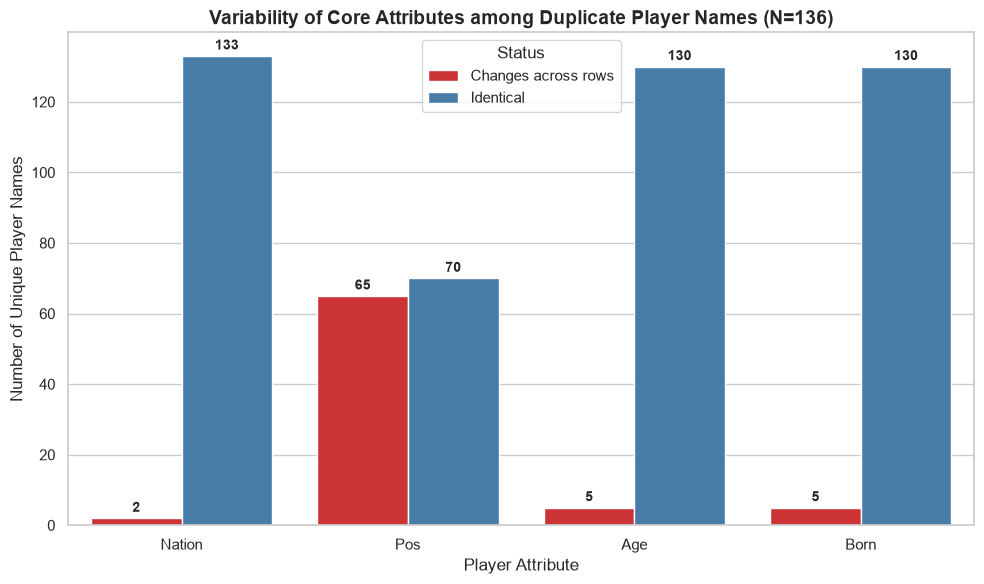

In [11]:
if duplicates_found:
    unique_counts = duplicate_players.groupby('Player')[['Nation', 'Pos', 'Age', 'Born']].nunique()

    changes = (unique_counts > 1).sum().reset_index()
    changes.columns = ['Attribute', 'Players_With_Changes']
    changes['Players_With_No_Changes'] = unique_counts.shape[0] - changes['Players_With_Changes']

    melted = changes.melt(id_vars='Attribute', var_name='Status', value_name='Count')
    melted['Status'] = melted['Status'].replace({
        'Players_With_Changes': 'Changes across rows',
        'Players_With_No_Changes': 'Identical'
    })

    plt.figure(figsize=(10, 6))
    sns.set_theme(style='whitegrid')
    ax = sns.barplot(data=melted, x='Attribute', y='Count', hue='Status', palette='Set1')
    plt.title(f'Variability of Core Attributes among Duplicate Player Names (N={duplicate_player_count})', fontsize=14, fontweight='bold')
    plt.xlabel('Player Attribute', fontsize=12)
    plt.ylabel('Number of Unique Player Names', fontsize=12)
    plt.legend(title='Status')

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

5 Players have different Born values, suggesting these may actually be two different players with a common name.
The same is true for Age, although these are likely the same players.

In [18]:
# find Players with multiple Born values
if duplicates_found:
    born_counts = duplicate_players.groupby('Player')['Born'].nunique()
    born_collision_players = born_counts[born_counts > 1].index

    born_collisions = duplicate_players[duplicate_players['Player'].isin(born_collision_players)].sort_values(by=['Player', 'Born'])

    display(born_collisions[['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born']])

,Player,Nation,Pos,Squad,Comp,Age,Born
799,Ederson,BRA,GK,Manchester City,Premier League,28.0,1993
798,Ederson,BRA,MF,Salernitana,Serie A,22.0,1999
2066,Joao Pedro,ITA,FW,Cagliari,Serie A,30.0,1992
2067,Joao Pedro,BRA,FWMF,Watford,Premier League,20.0,2001
1655,Marcelo,BRA,DF,Lyon,Ligue 1,35.0,1987
1654,Marcelo,BRA,DF,Bordeaux,Ligue 1,35.0,1987
1653,Marcelo,BRA,DF,Real Madrid,La Liga,34.0,1988
1036,Nicolas Gonzalez,ARG,FW,Fiorentina,Serie A,24.0,1998
1035,Nicolas Gonzalez,ESP,MF,Barcelona,La Liga,20.0,2002
2284,Rodrigo,ESP,MFFW,Leeds United,Premier League,31.0,1991


In [22]:
# find Players with different Ages, to check if they are the same
if duplicates_found:
    age_counts = duplicate_players.groupby('Player')['Age'].nunique()
    age_collision_players = age_counts[age_counts > 1].index

    age_collisions = duplicate_players[duplicate_players['Player'].isin(age_collision_players)].sort_values(by=['Player', 'Born'])

    if age_collisions.equals(born_collisions):
        print("The 'Born' overlaps are the same players as the 'Age' overlaps")

The 'Born' overlaps are the same players as the 'Age' overlaps


In [23]:
# Check the nationality overlaps
if duplicates_found:
    nation_counts = duplicate_players.groupby('Player')['Nation'].nunique()
    nation_collision_players = nation_counts[nation_counts > 1].index

    nation_collisions = duplicate_players[duplicate_players['Player'].isin(nation_collision_players)].sort_values(by=['Player', 'Born'])

    display(nation_collisions[['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born']])

,Player,Nation,Pos,Squad,Comp,Age,Born
2066,Joao Pedro,ITA,FW,Cagliari,Serie A,30.0,1992
2067,Joao Pedro,BRA,FWMF,Watford,Premier League,20.0,2001
1036,Nicolas Gonzalez,ARG,FW,Fiorentina,Serie A,24.0,1998
1035,Nicolas Gonzalez,ESP,MF,Barcelona,La Liga,20.0,2002


It is clear that the overlaps in Born, Age, and Nation are all due to different players sharing a common name. An identifying column can be made by combining these colums.

In [39]:
# add to the player_data dataframe as processing, and to duplicate_players for further pre-aggregating EDA

player_data['player_identifier'] = (
        player_data['Player'] + '_' + player_data['Nation'] + '_' + player_data['Born'].astype(str))

duplicate_players['player_identifier'] = (
        duplicate_players['Player'] + '_' + duplicate_players['Nation'] + '_' + duplicate_players['Born'].astype(str))


player_data[['Player', 'Nation', 'Age', 'Born', 'player_identifier']]

,Player,Nation,Age,Born,player_identifier
0,Max Aarons,ENG,22.0,2000,Max Aarons_ENG_2000
1,Yunis Abdelhamid,MAR,34.0,1987,Yunis Abdelhamid_MAR_1987
2,Salis Abdul Samed,GHA,22.0,2000,Salis Abdul Samed_GHA_2000
3,Laurent Abergel,FRA,29.0,1993,Laurent Abergel_FRA_1993
4,Charles Abi,FRA,22.0,2000,Charles Abi_FRA_2000
...,...,...,...,...,...
2916,Martin Zubimendi,ESP,23.0,1999,Martin Zubimendi_ESP_1999
2917,Szymon ?urkowski,POL,24.0,1997,Szymon ?urkowski_POL_1997
2918,Martin Odegaard,NOR,23.0,1998,Martin Odegaard_NOR_1998
2919,Milan ?uri?,BIH,32.0,1990,Milan ?uri?_BIH_1990


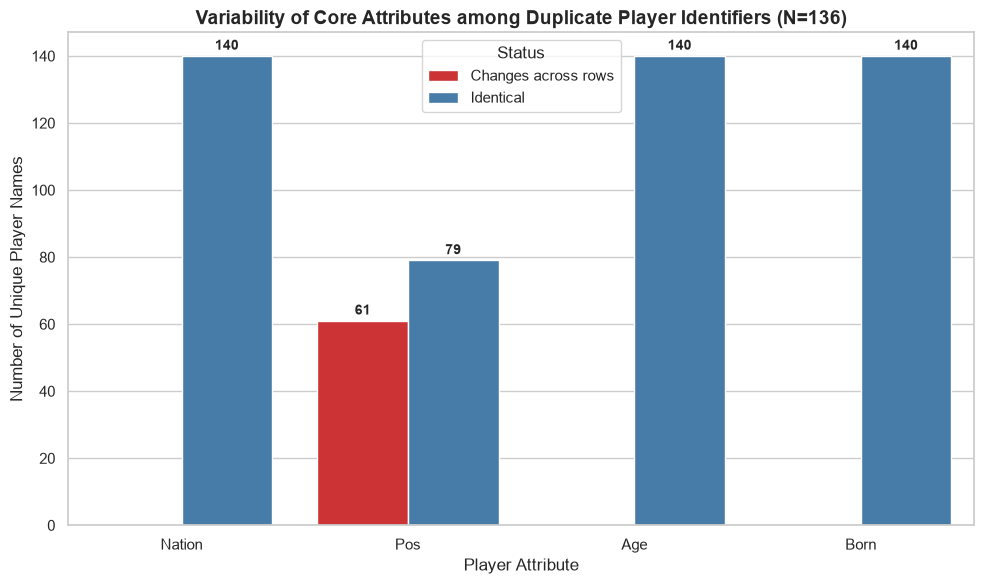

In [41]:
# Rerunning pre-aggregation checks using this new identifier:
if duplicates_found:
    unique_counts = duplicate_players.groupby('player_identifier')[['Nation', 'Pos', 'Age', 'Born']].nunique()

    changes = (unique_counts > 1).sum().reset_index()
    changes.columns = ['Attribute', 'Players_With_Changes']
    changes['Players_With_No_Changes'] = unique_counts.shape[0] - changes['Players_With_Changes']

    melted = changes.melt(id_vars='Attribute', var_name='Status', value_name='Count')
    melted['Status'] = melted['Status'].replace({
        'Players_With_Changes': 'Changes across rows',
        'Players_With_No_Changes': 'Identical'
    })

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=melted, x='Attribute', y='Count', hue='Status', palette='Set1')
    plt.title(f'Variability of Core Attributes among Duplicate Player Identifiers (N={duplicate_player_count})', fontsize=14, fontweight='bold')
    plt.xlabel('Player Attribute', fontsize=12)
    plt.ylabel('Number of Unique Player Names', fontsize=12)
    plt.legend(title='Status')

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

These has removed the majority of the crossovers, however there are stilla  significant number (61) of duplicate players with multiple positions.

In [44]:
# find Players with multiple Pos values
if duplicates_found:
    pos_counts = duplicate_players.groupby('player_identifier')['Pos'].nunique()
    pos_collision_players = pos_counts[pos_counts > 1].index

    pos_collisions = duplicate_players[duplicate_players['player_identifier'].isin(pos_collision_players)].sort_values(by=['player_identifier', 'Born'])

    display(pos_collisions[['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'player_identifier']])

,Player,Nation,Pos,Squad,Comp,Age,Born,player_identifier
2691,Adama Traore,ESP,FWDF,Barcelona,La Liga,26.0,1996,Adama Traore_ESP_1996
2692,Adama Traore,ESP,FW,Wolves,Premier League,26.0,1996,Adama Traore_ESP_1996
1611,Ainsley Maitland-Niles,ENG,DF,Roma,Serie A,24.0,1997,Ainsley Maitland-Niles_ENG_1997
1612,Ainsley Maitland-Niles,ENG,MF,Arsenal,Premier League,24.0,1997,Ainsley Maitland-Niles_ENG_1997
563,Andrea Conti,ITA,DFMF,Sampdoria,Serie A,28.0,1994,Andrea Conti_ITA_1994
...,...,...,...,...,...,...,...,...
1066,Sebastian Griesbeck,GER,MF,Union Berlin,Bundesliga,31.0,1990,Sebastian Griesbeck_GER_1990
2263,Tomas Rincon,VEN,MFFW,Torino,Serie A,34.0,1988,Tomas Rincon_VEN_1988
2264,Tomas Rincon,VEN,MF,Sampdoria,Serie A,34.0,1988,Tomas Rincon_VEN_1988
517,Xavier Chavalerin,FRA,MFFW,Troyes,Ligue 1,31.0,1991,Xavier Chavalerin_FRA_1991


This is due to players playing a different set of positions at different clubs. This leaves 5 options:
1. Treat the entries as distinct, as different positions are likely to have different metric profiles (will lead to multiple rows for some players, overweighting them in modelling)
2. Track all the positions played across the season, however this could lead to skewed data (as different positions will naturally lead to different performance metrics, but will be collapsed)
3. Remove the players entirely from the dataset (may skew the data as high-performers may be more likely to transfer)
4. Acquire more granular position data (ideal, but outside the scope of the MVP for this project)

For the MVP, and as the player's `Pos` values are already aggregated across the dataset (i.e. players can already have multiple positions), tracking all the positions played is justified. However, acquiring more granular detail will be an important discovery step for Phase 2.

The final major consideration for aggregating multi-row players is how to handle multiple `League` and `Club` values. While these won't be included as part of the player architecture modelling, they are very likely to be relevant to player value prediction. One-hot-encoding will be required for modelling anyway, but League can instead be transformed to a `{League Name}_pct_mins`, taking the percentage of the player's minute played in each of the 5 leagues included in the dataset. In order to scale this to more league's for future modelling, during Phase2 `League` can instead be replaced by some measure of league-level coefficient (e.g. UEFA coefficient for European clubs), with a weighted average being taken according to the `pct_mins` a player played in each league.

`Club` cannot be simply one-hot-encoded, as cardinality will be too high.


In [51]:
player_data.groupby(by='Pos')['player_identifier'].count().sort_values(ascending=False)

Pos
DF      942
MF      598
FW      419
FWMF    306
MFFW    239
GK      216
MFDF     68
DFMF     66
DFFW     35
FWDF     30
GKMF      1
Name: player_identifier, dtype: int64

In [52]:
# multi-position players are already concatenated into one string; all multi-position value can be converted to a list
